In [2]:
import polars as pl
import json
import matplotlib.pyplot as plt
import os 
import numpy as np 
from math import pi, sin, cos, sqrt

from post_process_parquet import data 

%matplotlib widget

In [14]:
results = data.group_by(
    pl.col("f")
).agg(
    pl.col("pow1").max().alias("pow1max"),
)

In [15]:
Ropt = []
for f in (results["f"]):
        p = results.filter(pl.col("f") == f)["pow1max"]
        d = data.filter((pl.col("f")==f) & (pl.col("pow1") == p))["Rload"]
        Ropt.append(d)

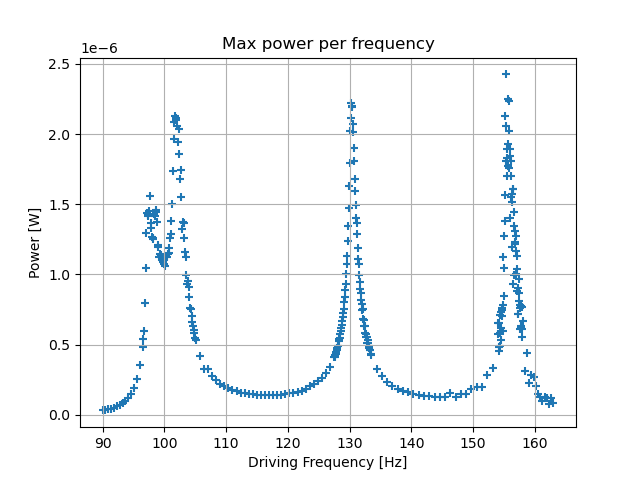

In [16]:
plt.figure()
plt.scatter(results["f"], results["pow1max"], marker='+')
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()

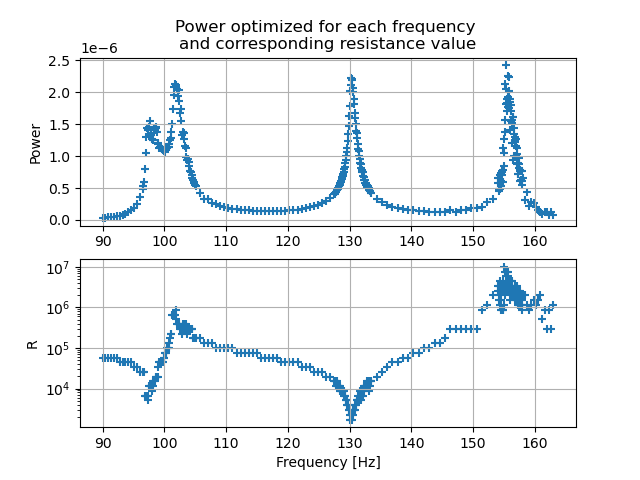

In [17]:
plt.figure()
plt.subplot(2, 1, 1)
plt.scatter(results["f"], results["pow1max"], marker='+')
plt.title('Power optimized for each frequency \nand corresponding resistance value')
plt.ylabel('Power')
plt.grid()

plt.subplot(2, 1, 2)
plt.scatter(results["f"], Ropt, marker='+')
plt.ylabel('R')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.grid()

plt.show()

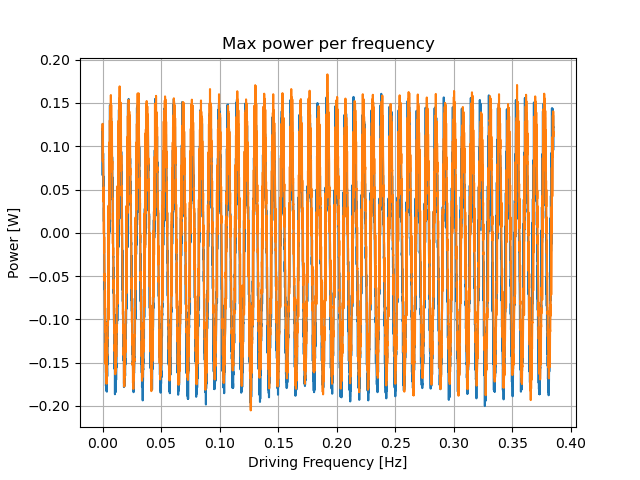

In [18]:
plt.figure()
plt.plot(data["time_meas"][150], data["acc1_temp"][150])
plt.plot(data["time_meas"][150], data["acc2_temp"][150])
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()

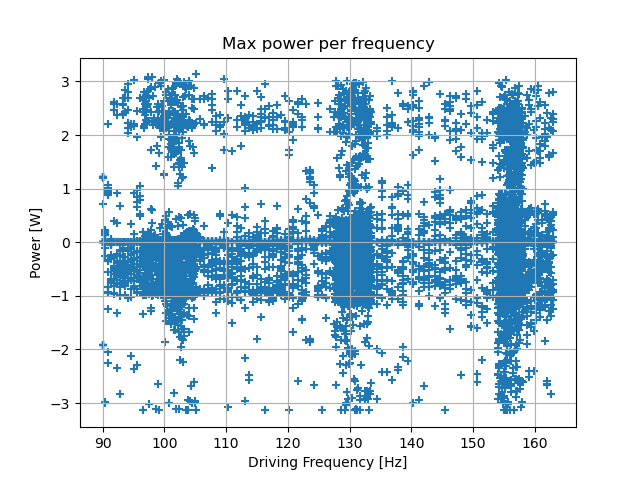

In [19]:
plt.figure()
plt.scatter(data["f"], data["phase_shift"], marker='+')
plt.xlabel("Driving Frequency [Hz]")
plt.ylabel("Power [W]")
plt.title("Max power per frequency")
plt.grid()
plt.show()